In [116]:
from sklearn.datasets import make_regression
import numpy as np

In [117]:
X, y = make_regression(
    n_samples=4,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=80,
    random_state=13
)


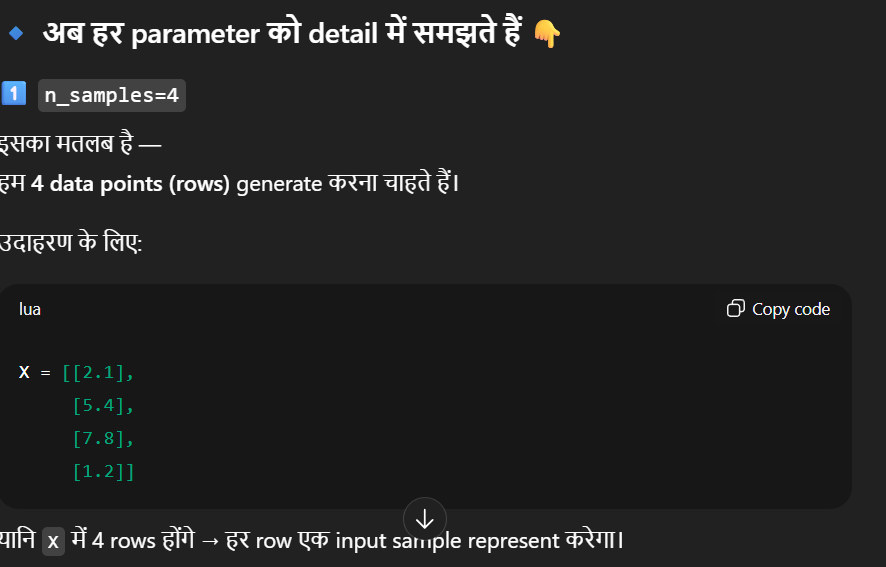

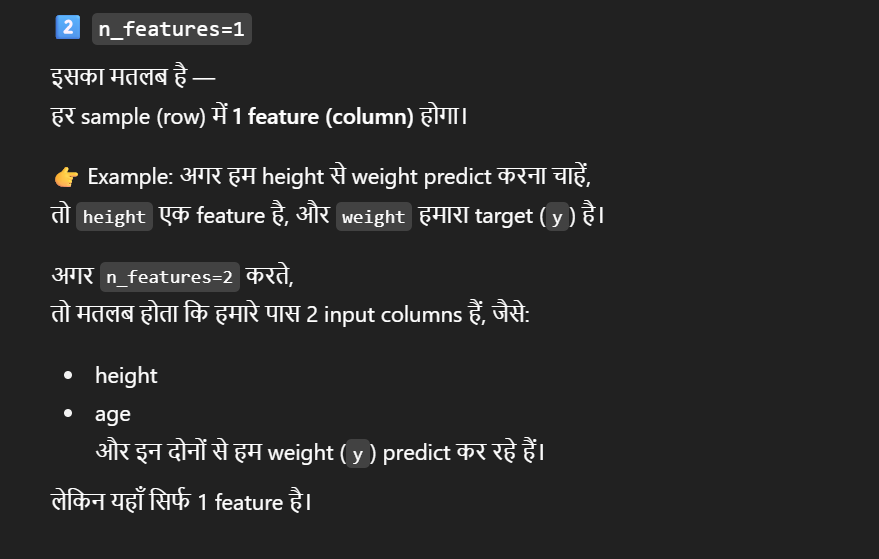

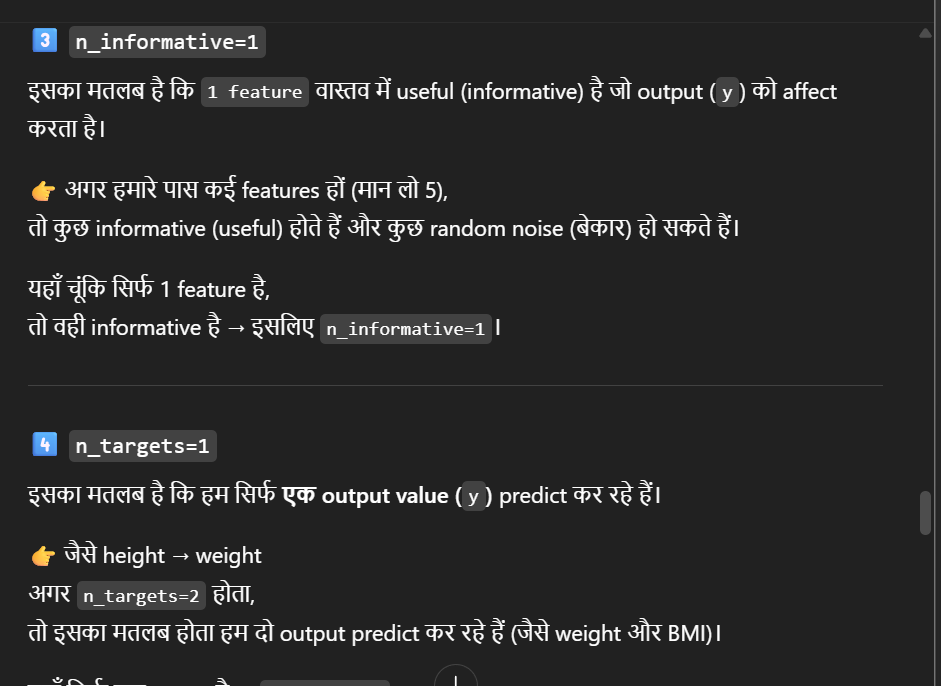

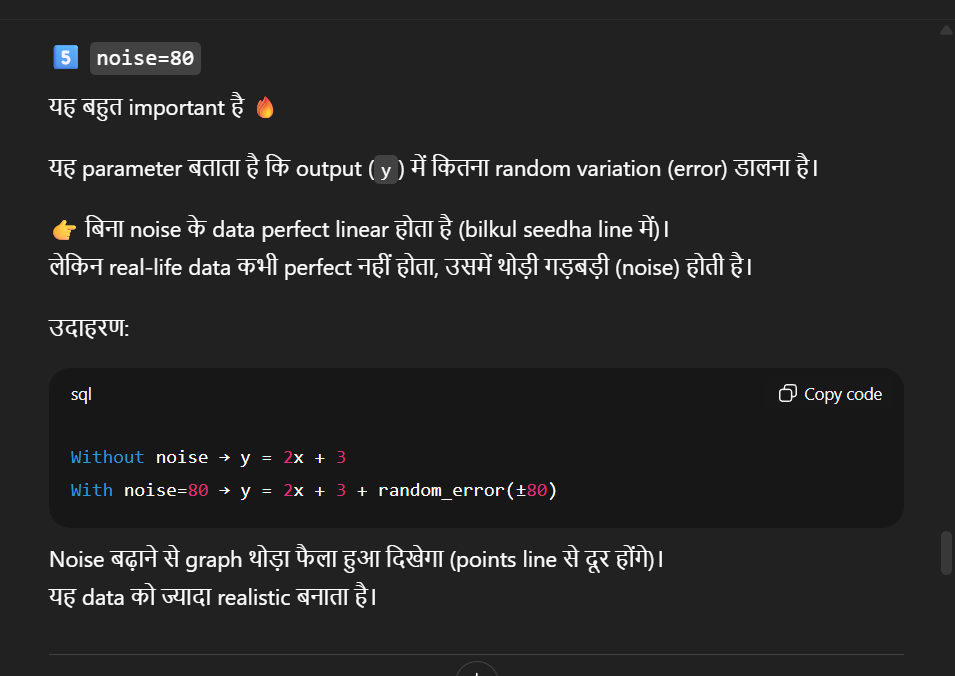

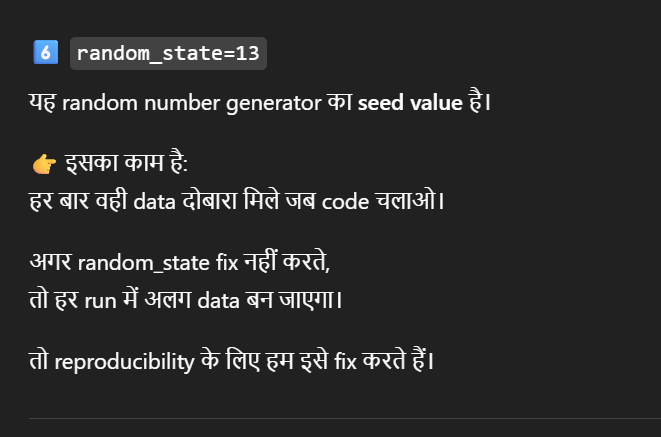

In [118]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [120]:
y

array([  7.21786552,  16.04609925, -27.83756166, 144.36688189])

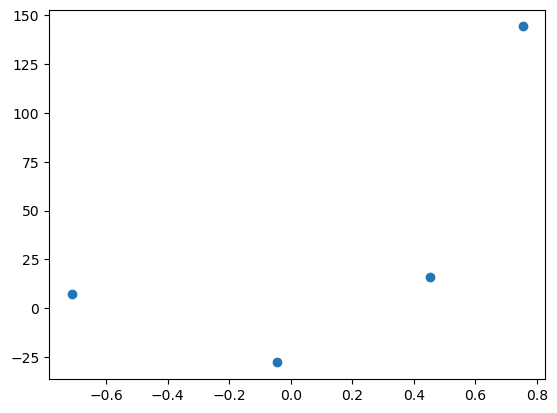

In [121]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [123]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression

In [124]:
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

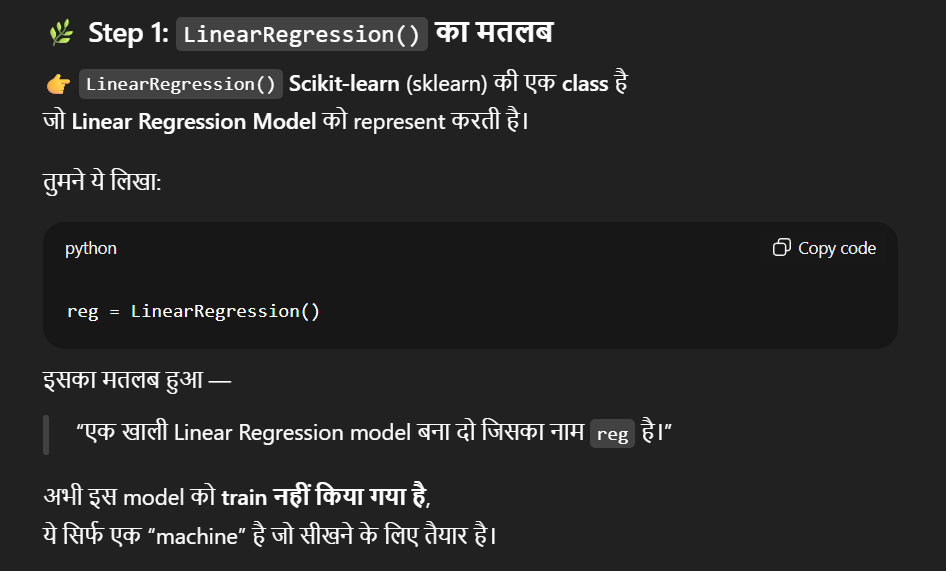

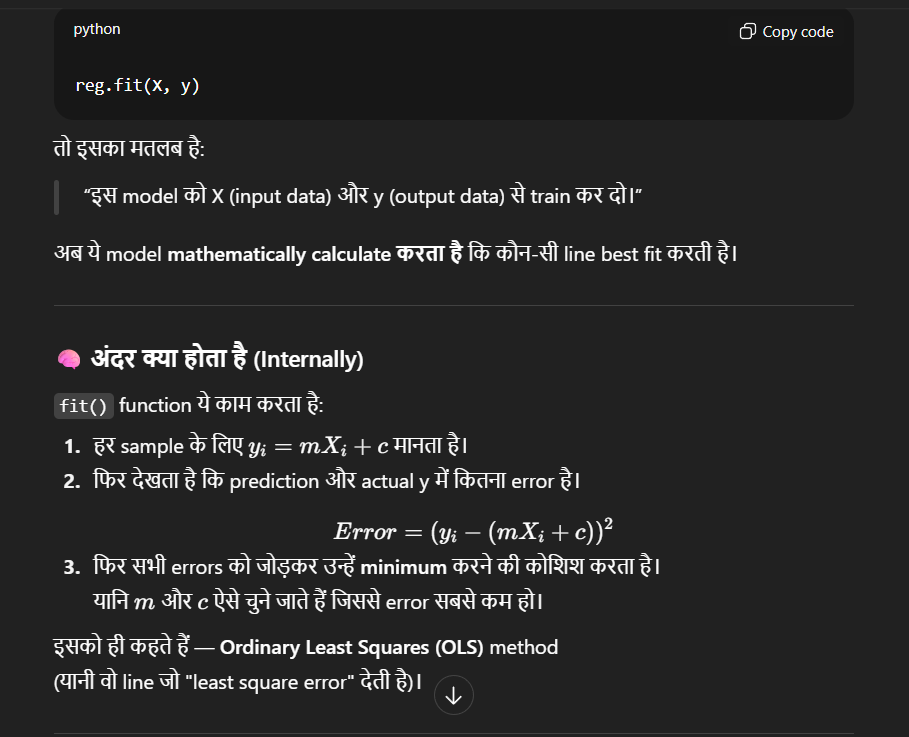

In [125]:
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None)

LinearRegression()

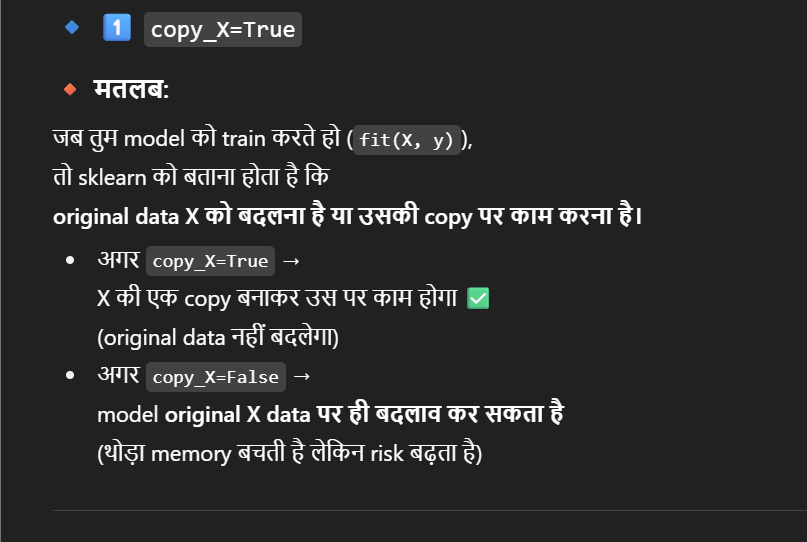

## 🧠 कब बदलते हैं?

### अगर तुम्हारा data बहुत बड़ा है (GBs में),
### और memory की कमी है, तब copy_X=False रख सकते हो।

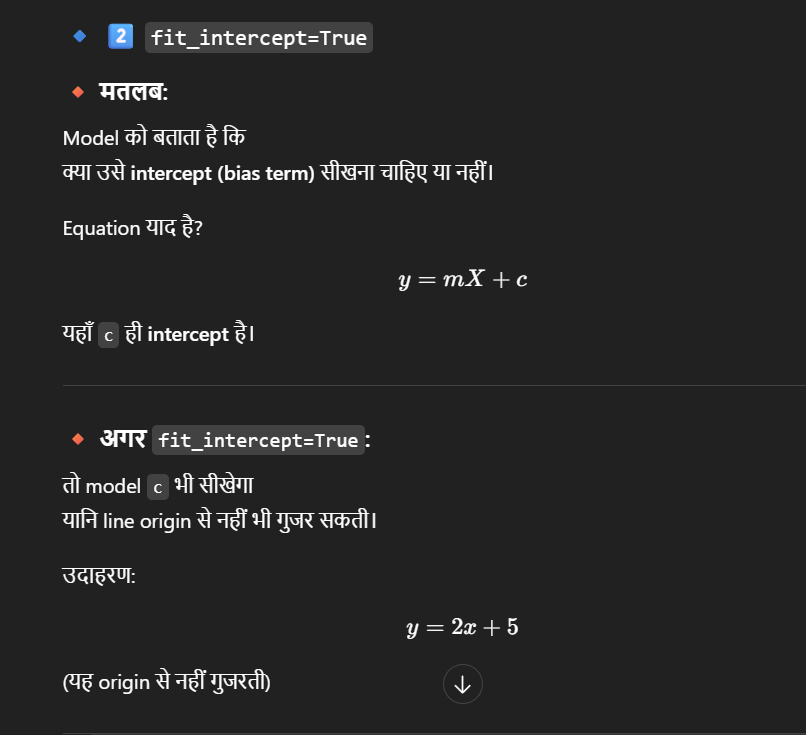

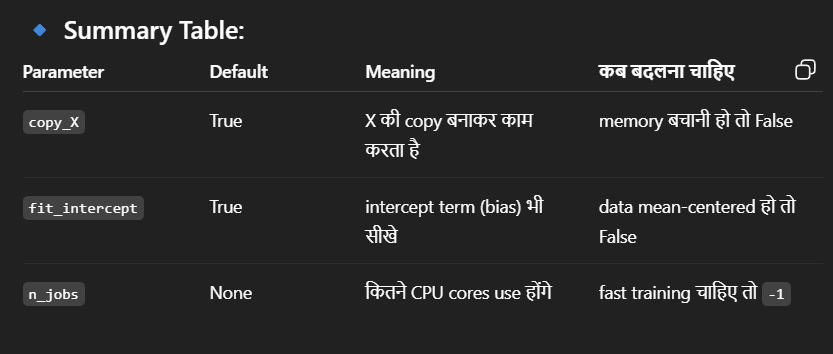

In [126]:
reg.coef_

# reg.coef_ = slope = m
# reg.intercept_ = intercept = c

array([78.35063668])

In [127]:
reg.intercept_

26.15963284313262

In [128]:
y

array([  7.21786552,  16.04609925, -27.83756166, 144.36688189])

In [129]:
reg.predict(X) 

array([-29.65662909,  61.55941724,  22.67278832,  85.21770852])

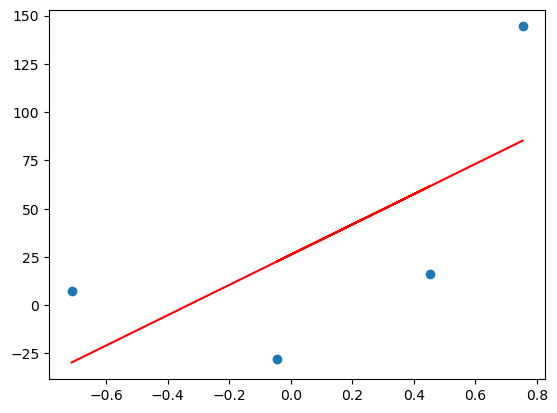

In [130]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [131]:
X  # ye tumhara 2d me hai 

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [132]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 0).reshape(4)

# .reshape(4) → इसे 1D array में convert करता है ताकि plotting (plt.plot) आसानी से हो सके

In [133]:
y_pred
# यह manual line है, जिसे तुमने खुद define किया:

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

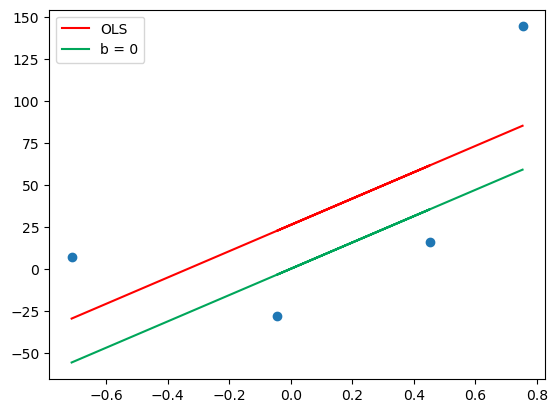

In [134]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()     

In [135]:
X.shape

(4, 1)

In [136]:
m = 78.35
b = 0
# y 1d me hai isiliye ise x ko bhi 1d me karna pada hai 
loss_slope = -2 * np.sum(y - m*X.ravel() - b)   # x tumaar 2d me hai isiliye isme hame ravel ka use karna pada hai 
loss_slope

-209.27763408209216

In [137]:
# lets take learning rate = 0.1
lr = 0.1
step_size = loss_slope * lr
step_size

-20.927763408209216

In [139]:
b = b - step_size  # abhi ham slope ko constant man ke chal rahe hai isiliye ham bas b ko hi update kar rahe hai 
b
# dekho pahle hamari b ki value 0 thi ab yha pe 20.927763408209216 itna ho gaya hai 

41.85552681641843

In [143]:
y_pred1 = ((78.35 * X) + b).reshape(4)
y_pred1

array([-13.96028156,  77.25502356,  38.36871063, 100.91312258])

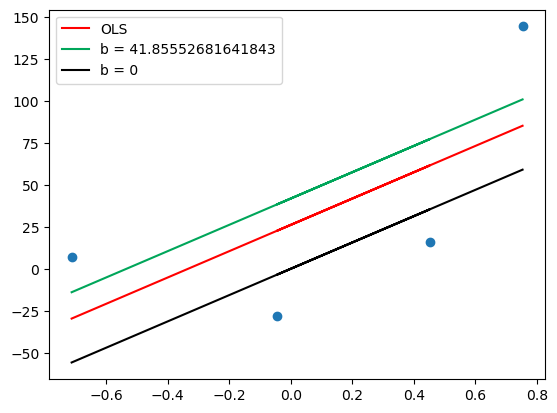

In [144]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label=f'b = {b}')
plt.plot(X,y_pred,color='black',label='b = 0')
plt.legend()
plt.show() 

# isme red wali line sabse sahi line hai 
# aur green line dusri prediction hai jab hamne b ko change kiya hai 
# aur black line wo hai jab b = 0 hai 

In [145]:
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

125.5665804492553

In [146]:
step_size = loss_slope * lr
step_size

12.55665804492553

In [147]:
b = b - step_size
b

# hamari actual b 26. something thi ab ham iske kareeb dheere pahuch rahe hai 

29.298868771492902

In [148]:
y_pred2 = ((78.35 * X) + b).reshape(4)

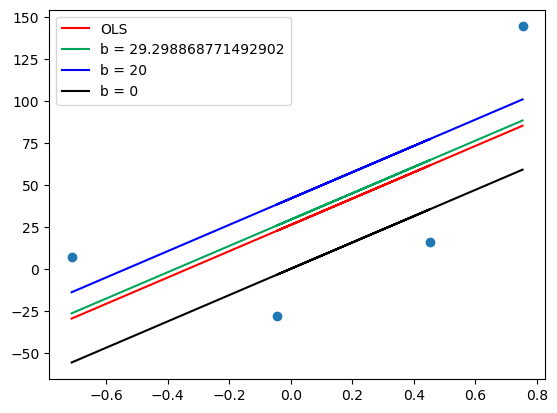

In [149]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label=f'b = {b}')
plt.plot(X,y_pred1,color='blue',label='b = 20')
plt.plot(X,y_pred,color='black',label='b = 0')
plt.legend()
plt.show() 

# dekho yaha green line almost usi ke upar hi pahuch gaya hai 

In [150]:
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

25.113316089851054

In [151]:
step_size = loss_slope * lr
step_size

2.5113316089851057

In [152]:
b = b - step_size
b

26.787537162507796

In [153]:
y_pred3 = ((78.35 * X) + b).reshape(4)

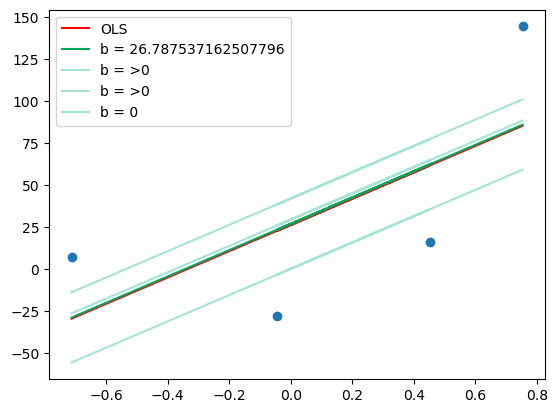

In [154]:
# plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label=f'b = {b}')
plt.plot(X,y_pred2,color='#A3E4D7',label='b = >0')
plt.plot(X,y_pred1,color='#A3E4D7',label='b = >0')
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

# isme dekho dono line ek dusre ke upar hi hai 

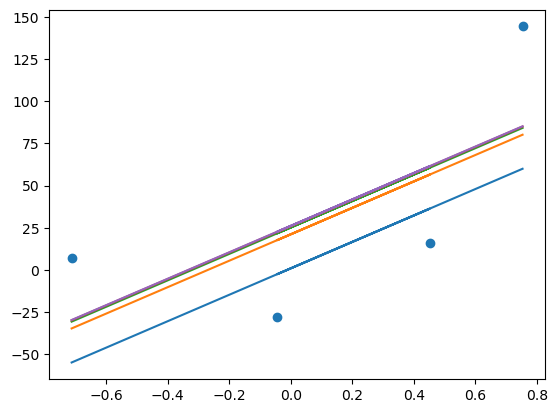

In [157]:
b = -100
m = 78.35
lr = 0.1

epochs = 5

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b
  
  plt.plot(X,y_pred)

plt.scatter(X,y)

# PART-2

In [93]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [158]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)


In [159]:
X

array([[-0.71239066],
       [-0.43714566],
       [-0.45375238],
       [ 0.95283061],
       [ 0.23785784],
       [ 0.86121137],
       [-0.24332625],
       [ 0.18494595],
       [-0.72099967],
       [-0.42989708],
       [ 2.01522083],
       [ 0.39724133],
       [ 0.20780005],
       [-0.23242587],
       [-0.76862702],
       [ 0.45315861],
       [ 0.63988397],
       [ 0.3595323 ],
       [-1.61510796],
       [ 1.74924179],
       [-0.78898902],
       [-0.51196509],
       [-0.92833523],
       [ 2.15038297],
       [-0.2073497 ],
       [-1.63909341],
       [-0.33861825],
       [-0.32212366],
       [-0.48137142],
       [-0.52316421],
       [ 0.72196506],
       [ 0.76591105],
       [ 0.45348104],
       [-1.26160595],
       [-2.18711527],
       [-1.18541881],
       [ 0.21745166],
       [ 1.33031692],
       [-1.08718159],
       [ 0.56226171],
       [-1.51284512],
       [-0.00238903],
       [-0.27813452],
       [ 0.45181234],
       [ 1.19070527],
       [ 0

In [160]:
y

array([-3.43198806e+01, -9.42120961e+00, -1.90881877e+01,  2.04372122e+01,
        2.77559659e+01, -2.90750046e+00, -1.41987828e+01,  5.40025891e+00,
       -2.64264302e+01, -3.49067872e+01,  3.73362043e+01,  1.28532816e+01,
        2.50289888e+01, -1.89608736e+01, -2.34655852e+01,  3.77839324e+01,
        6.69670792e+00, -5.57201352e+00, -4.92158778e+01,  1.59474399e+01,
       -4.29667324e+01,  6.09015466e+00, -2.53194769e+01,  6.28216706e+01,
        1.24870400e+01, -3.27136530e+01, -1.88255476e+01, -2.93912926e+01,
       -2.86886731e+01,  4.38924069e+00,  4.63542396e+01,  2.43919519e+01,
        3.79848517e+01, -3.45767718e+01, -6.18736296e+01, -4.64421597e+01,
       -6.88808416e+00,  3.96988084e+01, -3.52373298e+01,  8.36850884e+00,
       -3.96814412e+01,  8.27318308e+00, -4.40722161e+00, -3.01350607e+00,
        5.78213629e+01,  2.46525603e+01,  1.81131707e+01, -5.22849035e+01,
        3.59187182e+01,  1.58411788e+01,  2.40080546e+01, -2.51245994e+01,
       -4.39284313e+01,  

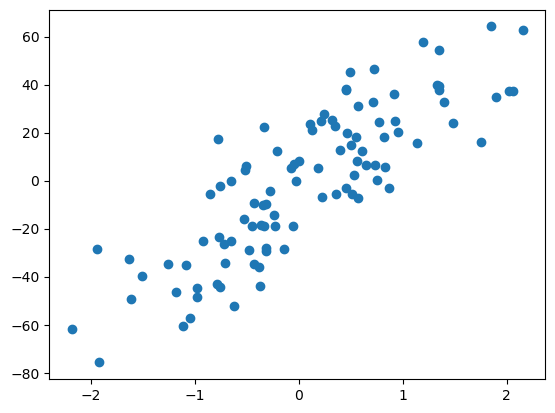

In [161]:
plt.scatter(X,y)

In [162]:
from sklearn.linear_model import LinearRegression

In [163]:
lr = LinearRegression()

In [164]:
lr.fit(X,y)

LinearRegression()

In [165]:
lr.coef_

array([27.82809103])

In [166]:
print(lr.coef_)

[27.82809103]


In [167]:
lr.intercept_

-2.29474455867698

In [168]:
# isme ham m ko constant maan ke chal rahe hai kewal b ko hi var maan ke chal rahe hai 

class GDRegressor :
    def __init__(self,learning_rate,epochs):
        self.m = 27.82809103
        self.b = 120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # calculate the b using b
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.lr * loss_slope)
            print(loss_slope,self.b)
        print(self.b)

In [169]:
gd = GDRegressor(0.001,50)

# pahle jab hamne lr ko 0.1 kiya tha to b ki value aa rhi thi a
# aur jab aisa ho to aapko lr ko kam karna hota hai aur epochs ki value ko badhane padta hai 
# aisa karne se tumhara b ki value almost original value ke kareeb aa jati hai 

In [170]:
gd.fit(X,y)

24458.948911705953 95.54105108829404
19567.15912936476 75.97389195892927
15653.727303491813 60.32016465543746
12522.98184279345 47.79718281264401
10018.38547423476 37.77879733840925
8014.708379387808 29.76408895902144
6411.766703510245 23.352322255511194
5129.4133628081945 18.222908892703
4103.530690246557 14.119378202456442
3282.824552197246 10.836553650259196
2626.2596417577965 8.2102940085014
2101.0077134062376 6.109286295095162
1680.8061707249894 4.428480124370172
1344.6449365799915 3.083835187790181
1075.7159492639933 2.008119238526188
860.5727594111947 1.1475464791149932
688.4582075289555 0.4590882715860376
550.7665660231646 -0.09167829443712705
440.6132528185317 -0.5322915472556587
352.49060225482515 -0.884782149510484
281.99248180386024 -1.1667746313143441
225.5939854430883 -1.3923686167574325
180.47518835447062 -1.5728438051119031
144.38015068357652 -1.7172239557954796
115.5041205468612 -1.8327280763423408
92.40329643748882 -1.9251313727798296
73.92263714999106 -1.999054009929

# PART - 3

##### is part me ham b aur m dono ko variable maan chalenge 

In [171]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [172]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)


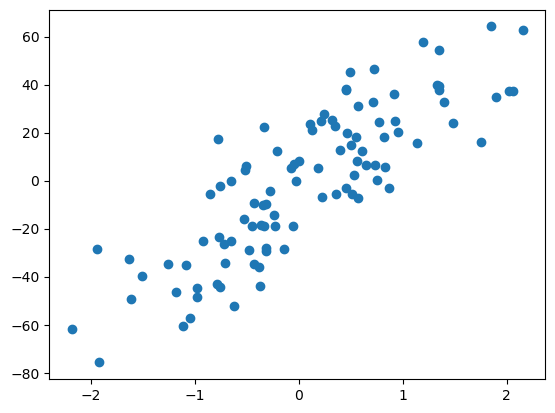

In [174]:
plt.scatter(X,y)

In [175]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [176]:
from sklearn.linear_model import LinearRegression

In [177]:
lr = LinearRegression()

In [178]:
lr.fit(X_train,y_train)

LinearRegression()

In [179]:
lr.coef_

array([28.12597332])

In [180]:
lr.intercept_

-2.2710144261783825

In [181]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [182]:
 class GDRegressor :
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = 120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # calculate the b using b
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            
        print(self.m,self.b)

    def predict(self,X):
        return self.m * X + self.b

In [183]:
gd = GDRegressor(0.001,100)

In [184]:
gd.fit(X_train,y_train)

28.12597412192845 -2.271012459583283


In [186]:

y_pred = gd.predict(X_test)

from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158732447627